## Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import math
from torch.utils.tensorboard import SummaryWriter 
import json
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.manifold import spectral_embedding
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import rbf_kernel

## Import Dataset Classes

In [3]:
from dataset_classes import ISO_NE, AT, SH_Dataset

## Import Model

In [4]:
from models_with_temporal_graph import TR_GNN_MultiScale

## Import Training and Testing Loops

In [5]:
from helper_functions import train_model, test_model, test_model_stepwise, validate

# Sensitivity SH

In [5]:
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    SAVE_DIR = "Intial_Paper/TR_GNN_SH_Sensitivity"
    os.makedirs(SAVE_DIR, exist_ok=True)

    # --- Load dataset (unscaled) ---
    dataset = SH_Dataset(
        csv_path="sh_dataset.csv", 
        T_in=72,
        T_out=240,
        lag_hours=[1, 12, 24, 168], 
        rolling_windows=[12, 24],
    )
    
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    
    print("\n🔍 Generating Feature Clusters...")
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  
    
    train_end = train_split_idx - dataset.T_in - dataset.T_out
    val_start = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in - dataset.T_out
    test_start = val_split_idx - dataset.T_in
    
    effective_len = len(dataset)
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(val_start, val_end)
    test_idx = range(test_start, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    # DataLoaders can be reused since batch_size doesn't change in this sensitivity analysis
    base_batch_size = 32
    train_loader = DataLoader(train_subset, batch_size=base_batch_size, shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=base_batch_size, shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=base_batch_size, shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

    # --- Define Static Hyperparameters ---
    static_hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": base_batch_size, 
        "epochs": 100,
        "weight_decay": 1e-3, 
    }

    # --- Define Sensitivity Analysis Grids ---
    baseline_params = {
        "kernel_size": 7,
        "GCN_Layer": 5, # Referred to as GCN_Depth in prompt
        "dilation": 3,
        "hidden_dim": 64
    }

    sensitivity_grids = {
        "kernel_size": [3, 5, 11],
        "GCN_Layer": [1, 2, 3, 7],
        "dilation": [1, 2, 5],
        "hidden_dim": [32, 128, 256]
    }

    # Build the list of experiments (Baseline + One-at-a-time variations)
    experiments = [("Baseline", baseline_params.copy())]
    
    for param_name, values in sensitivity_grids.items():
        for val in values:
            # Copy baseline and change just the one parameter
            exp_params = baseline_params.copy()
            exp_params[param_name] = val
            run_name = f"{param_name}_{val}"
            experiments.append((run_name, exp_params))

    print(f"\n📊 Starting Sensitivity Analysis for {len(experiments)} total configurations.\n")

    criterion = nn.MSELoss()
    all_results = {}

    # --- Run / Re-evaluate Experiments ---
    for exp_name, exp_params in experiments:
        print(f"{'='*60}")
        print(f"🚀 Running Experiment: {exp_name}")
        print(f"Config: {exp_params}")
        print(f"{'='*60}")

        current_hparams = {**static_hparams, **exp_params}

        model = TR_GNN_MultiScale(
            N=current_hparams["N"],
            T_in=current_hparams["T_in"],
            T_out=current_hparams["T_out"],
            d=current_hparams["d"],
            hidden_dim=current_hparams["hidden_dim"],
            GCN_Layer=current_hparams["GCN_Layer"],
            dropout_gcn=current_hparams["dropout_gcn"],
            dropout_temporal=current_hparams["dropout_temporal"],
            kernel_size=current_hparams["kernel_size"],
            dilation=current_hparams["dilation"],
        ).to(device)

        run_title = f"TR_GNN_SH_Sensitivity/{exp_name}"
        weights_path = f"Intial_Paper/{run_title}_best_model.pth"

        try:
            avg_epoch_time_s = None
            peak_gpu_mem_mb = None

            if os.path.exists(weights_path):
                print(f"⏭️  Found existing weights — skipping training: {weights_path}")
                model.load_state_dict(torch.load(weights_path, map_location=device))
            else:
                log_dir = f"TR_GNN_SH/{run_title}"
                writer = SummaryWriter(log_dir)
                writer.add_text("hparams", json.dumps(current_hparams, indent=2))

                if device == "cuda":
                    torch.cuda.reset_peak_memory_stats(device)

                model = train_model(
                    model,
                    train_loader,
                    val_loader,
                    epochs=current_hparams["epochs"],
                    lr=current_hparams["lr"],
                    device=device,
                    scheduler_patience=current_hparams["scheduler_patience"],
                    writer=writer,
                    weight_decay=current_hparams["weight_decay"],
                    save_path=weights_path,
                )
                writer.close()

                avg_epoch_time_s = getattr(model, "_avg_epoch_time_s", None)
                if device == "cuda":
                    peak_gpu_mem_mb = float(
                        torch.cuda.max_memory_allocated(device) / (1024 ** 2)
                    )

            # --- Validation (best-checkpoint val loss) ---
            best_val_loss = validate(model, val_loader, criterion, device)

            # --- Test + inference timing ---
            print(f"\n🧪 Testing {exp_name}...")
            model.eval()
            preds_all, trues_all, batch_times_ms = [], [], []
            with torch.no_grad():
                for X, Y in tqdm(test_loader, desc=f"Test {exp_name}", leave=False):
                    X = X.to(device)
                    Y = Y.to(device)
                    if device == "cuda":
                        torch.cuda.synchronize()
                    t0 = time.time()
                    out, _ = model(X)
                    if device == "cuda":
                        torch.cuda.synchronize()
                    batch_times_ms.append((time.time() - t0) * 1000.0)
                    preds_all.append(out.cpu().numpy())
                    trues_all.append(Y.cpu().numpy())

            avg_inference_ms = float(np.mean(batch_times_ms)) if batch_times_ms else None

            preds_flat = np.concatenate(preds_all, axis=0).flatten()
            trues_flat = np.concatenate(trues_all, axis=0).flatten()

            n_total = len(preds_flat)
            n_features = len(dataset.feature_names)
            target_col = dataset.target_idx
            dummy_p = np.zeros((n_total, n_features))
            dummy_t = np.zeros((n_total, n_features))
            dummy_p[:, target_col] = preds_flat
            dummy_t[:, target_col] = trues_flat
            preds_unscaled = dataset.scaler.inverse_transform(dummy_p)[:, target_col]
            trues_unscaled = dataset.scaler.inverse_transform(dummy_t)[:, target_col]

            test_mse = float(mean_squared_error(trues_unscaled, preds_unscaled))
            test_mae = float(mean_absolute_error(trues_unscaled, preds_unscaled))
            test_r2  = float(r2_score(trues_unscaled, preds_unscaled))

            n_params = int(sum(p.numel() for p in model.parameters() if p.requires_grad))

            all_results[exp_name] = {
                "status": "OK",
                "GCN_Layer": current_hparams["GCN_Layer"],
                "hidden_dim": current_hparams["hidden_dim"],
                "kernel_size": current_hparams["kernel_size"],
                "dilation": current_hparams["dilation"],
                "n_params": n_params,
                "best_val_loss": float(best_val_loss),
                "avg_epoch_time_s": avg_epoch_time_s,
                "peak_gpu_mem_mb": peak_gpu_mem_mb,
                "avg_inference_ms": avg_inference_ms,
                "test_mse": test_mse,
                "test_mae": test_mae,
                "test_r2": test_r2,
                "model_path": weights_path,
                "train_losses": [],
                "val_losses": [],
                "beats_baseline": False,  # filled in below
            }
            epoch_str = (
                f"{avg_epoch_time_s:.1f}s/ep" if avg_epoch_time_s is not None else "—"
            )
            gpu_str = (
                f"{peak_gpu_mem_mb:.0f}MB GPU" if peak_gpu_mem_mb is not None else "—"
            )
            print(
                f"   ↳ val={best_val_loss:.6f} | test_mse={test_mse:.4f} | "
                f"test_mae={test_mae:.4f} | test_r2={test_r2:.4f} | "
                f"inf={avg_inference_ms:.2f} ms/batch | "
                f"{epoch_str} | {gpu_str}"
            )

        except Exception as e:
            print(f"❌ {exp_name} failed: {e}")
            all_results[exp_name] = {
                "status": f"FAILED: {e}",
                "GCN_Layer": current_hparams.get("GCN_Layer"),
                "hidden_dim": current_hparams.get("hidden_dim"),
                "kernel_size": current_hparams.get("kernel_size"),
                "dilation": current_hparams.get("dilation"),
                "n_params": None,
                "best_val_loss": float("inf"),
                "avg_epoch_time_s": None,
                "peak_gpu_mem_mb": None,
                "avg_inference_ms": None,
                "test_mse": None,
                "test_mae": None,
                "test_r2": None,
                "model_path": weights_path,
                "train_losses": [],
                "val_losses": [],
                "beats_baseline": False,
            }

        print(f"✅ Finished Experiment: {exp_name}\n")

    # --- Mark beats_baseline ---
    baseline_val = all_results.get("Baseline", {}).get("best_val_loss", float("inf"))
    for k, v in all_results.items():
        if k == "Baseline" or v.get("status") != "OK":
            continue
        v["beats_baseline"] = v["best_val_loss"] < baseline_val

    # --- Persist a JSON snapshot so we don't need to re-test next time ---
    snapshot_path = os.path.join(SAVE_DIR, "all_results.json")
    try:
        with open(snapshot_path, "w") as f:
            json.dump(all_results, f, indent=2, default=float)
        print(f"💾 Saved results snapshot → {snapshot_path}")
    except Exception as e:
        print(f"⚠️  Could not write {snapshot_path}: {e}")

    return all_results, SAVE_DIR, dataset, test_loader, static_hparams


all_results, SAVE_DIR, dataset, test_loader, static_hparams = main()

Loaded dataset with 25 features (target=load), total rows=17258
Raw data length: 17258
Scaler 'train_size' (raw rows): 10354
Scaler 'val_end' (raw rows): 13806

🔍 Generating Feature Clusters...
Total valid samples: 16946
Train samples: 10042, Val samples: 3212, Test samples: 3212

🚚 DataLoaders ready. Train batches: 314, Val batches: 101, Test batches: 101

📊 Starting Sensitivity Analysis for 14 total configurations.

🚀 Running Experiment: Baseline
Config: {'kernel_size': 7, 'GCN_Layer': 5, 'dilation': 3, 'hidden_dim': 64}


Epoch 1/100: 100%|██████████| 314/314 [00:04<00:00, 77.93it/s, mse=0.2480, smooth=0.0057] 


Epoch 001 | Train Loss: 0.8359 | Val Loss: 0.5968 | LR: 0.000100
✅ New best model saved (Val Loss: 0.596846)


Epoch 2/100: 100%|██████████| 314/314 [00:03<00:00, 98.33it/s, mse=0.2499, smooth=0.0054] 


Epoch 002 | Train Loss: 0.4994 | Val Loss: 0.4532 | LR: 0.000100
✅ New best model saved (Val Loss: 0.453244)


...

Epoch 064 | Train Loss: 0.2058 | Val Loss: 0.2117 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 65/100: 100%|██████████| 314/314 [00:03<00:00, 104.13it/s, mse=0.0710, smooth=0.0051]


Epoch 065 | Train Loss: 0.2056 | Val Loss: 0.2111 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

               TIMING REPORT               
⏱️  Time to reach Best Model: 3m 4s
⏱️  Total Training Duration:  3m 38s

Loading best model from Intial_Paper/TR_GNN_SH_Sensitivity/hidden_dim_256_best_model.pth (Val Loss: 0.209785)
Training complete. TensorBoard logs saved.



🧪 Testing hidden_dim_256...


   ↳ val=0.209785 | test_mse=3059034.6581 | test_mae=1276.8952 | test_r2=0.7949 | inf=2.12 ms/batch | 3.4s/ep | 218MB GPU
✅ Finished Experiment: hidden_dim_256

💾 Saved results snapshot → Intial_Paper/TR_GNN_SH_Sensitivity/all_results.json


## Summary DataFrame

In [6]:
rows = []
BASELINE_VAL_LOSS = all_results.get("Baseline", {}).get("best_val_loss", float("inf"))

for cfg_name, r in all_results.items():
    base = dict(
        config=cfg_name,
        **{
            k: r.get(k)
            for k in [
                "GCN_Layer",
                "hidden_dim",
                "kernel_size",
                "dilation",
                "n_params",
                "best_val_loss",
                "avg_epoch_time_s",
                "peak_gpu_mem_mb",
                "avg_inference_ms",
                "test_mse",
                "test_mae",
                "test_r2",
                "beats_baseline",
                "model_path",
                "status",
                "train_losses",
                "val_losses",
            ]
        }
    )
    rows.append(base)

df_results = pd.DataFrame(rows)

print(
    df_results[
        [
            "config",
            "best_val_loss",
            "test_mse",
            "test_mae",
            "test_r2",
            "avg_epoch_time_s",
            "peak_gpu_mem_mb",
            "avg_inference_ms",
            "beats_baseline",
        ]
    ].to_string(index=False)
)

        config  best_val_loss     test_mse    test_mae  test_r2  avg_epoch_time_s  peak_gpu_mem_mb  avg_inference_ms  beats_baseline
      Baseline       0.210158 2.916938e+06 1246.096500 0.804474          2.849546        64.520020          1.452019           False
 kernel_size_3       0.208062 3.025804e+06 1275.615067 0.797177          2.856052        64.556152          1.475145            True
 kernel_size_5       0.214389 2.995730e+06 1255.149580 0.799193          2.909046        64.604980          1.316821           False
kernel_size_11       0.203656 3.116504e+06 1285.580594 0.791097          2.847328        64.751465          1.325515            True
   GCN_Layer_1       0.210151 2.909984e+06 1234.111395 0.804940          2.400697        64.395996          1.297302            True
   GCN_Layer_2       0.204650 2.829884e+06 1223.108802 0.810310          2.416070        64.460449          1.362055            True
   GCN_Layer_3       0.206066 2.861791e+06 1226.479639 0.808171      

## CSV Export

In [7]:
csv_cols = [
    "config", "GCN_Layer", "hidden_dim", "kernel_size", "dilation",
    "n_params", "best_val_loss", "test_mse", "test_mae", "test_r2",
    "avg_epoch_time_s", "avg_inference_ms", "peak_gpu_mem_mb",
    "beats_baseline", "model_path", "status",
]

csv_path = os.path.join(SAVE_DIR, "sensitivity_analysis_results.csv")
df_results[csv_cols].to_csv(csv_path, index=False)
print(f"✅ CSV saved → {csv_path}")

✅ CSV saved → Intial_Paper/TR_GNN_SH_Sensitivity/sensitivity_analysis_results.csv


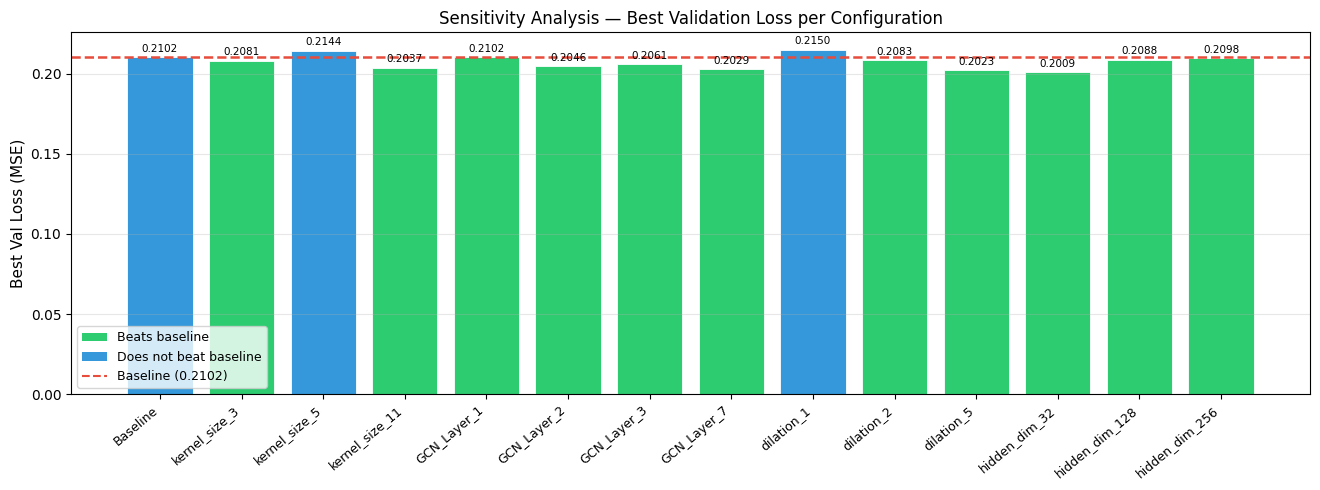

  📊 Saved: summary_val_loss_bar.png


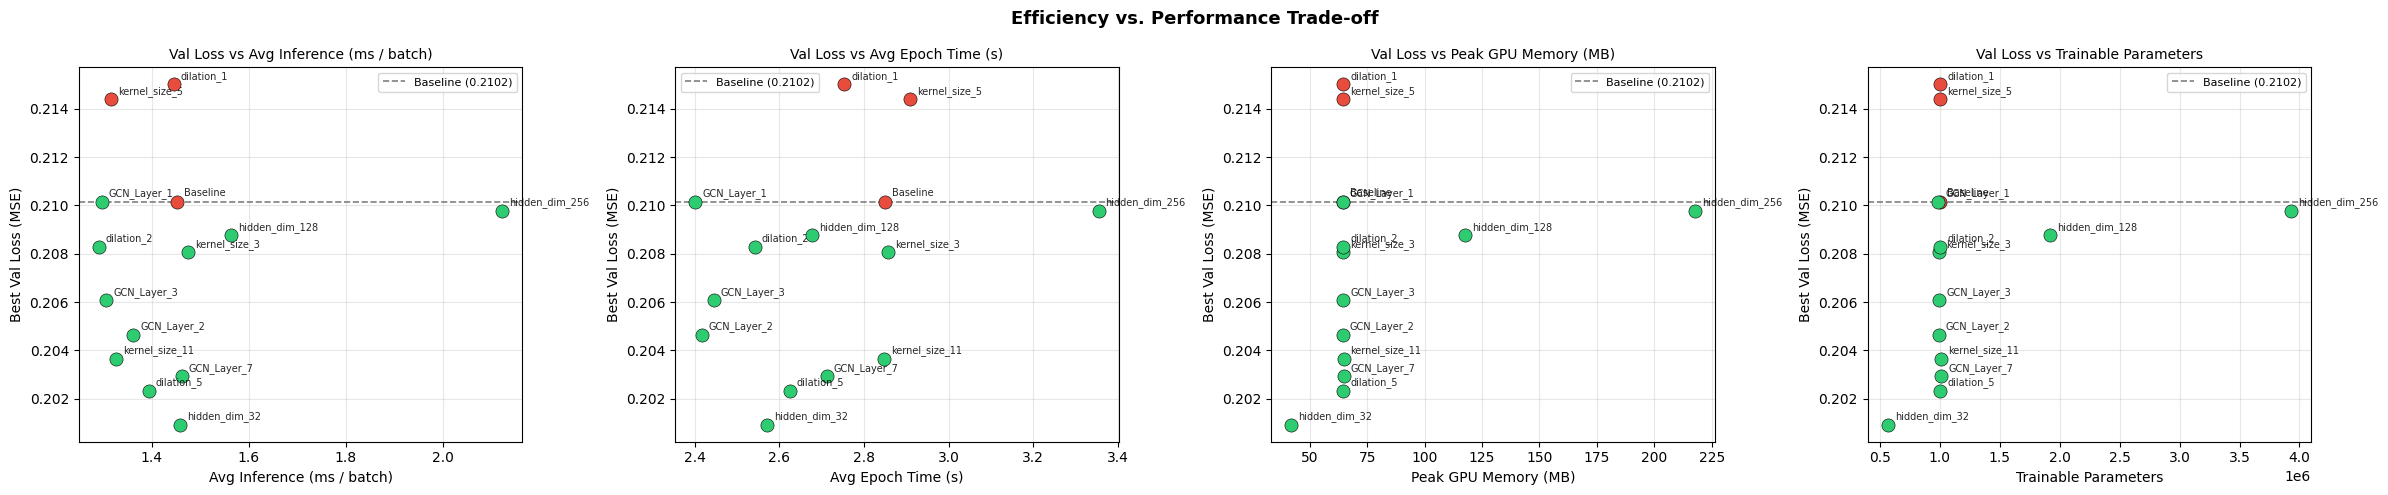

  📈 Saved: efficiency_scatter.png

✅ All outputs written to:  Intial_Paper/TR_GNN_SH_Sensitivity/
   📊  CSV    : sensitivity_analysis_results.csv
   📈  Figures: loss_curves/  (bar + scatter + 4 group loss PNGs)

🏆 11 config(s) beat the baseline:
   • kernel_size_3             | Val 0.2081 | Intial_Paper/TR_GNN_SH_Sensitivity/kernel_size_3_best_model.pth
   • kernel_size_11            | Val 0.2037 | Intial_Paper/TR_GNN_SH_Sensitivity/kernel_size_11_best_model.pth
   • GCN_Layer_1               | Val 0.2102 | Intial_Paper/TR_GNN_SH_Sensitivity/GCN_Layer_1_best_model.pth
   • GCN_Layer_2               | Val 0.2046 | Intial_Paper/TR_GNN_SH_Sensitivity/GCN_Layer_2_best_model.pth
   • GCN_Layer_3               | Val 0.2061 | Intial_Paper/TR_GNN_SH_Sensitivity/GCN_Layer_3_best_model.pth
   • GCN_Layer_7               | Val 0.2029 | Intial_Paper/TR_GNN_SH_Sensitivity/GCN_Layer_7_best_model.pth
   • dilation_2                | Val 0.2083 | Intial_Paper/TR_GNN_SH_Sensitivity/dilation_2_best_mode

In [8]:
# ============================================================
# SENSITIVITY SH — Bar Plot, Efficiency Scatter & Final Summary
# ============================================================
from matplotlib.patches import Patch

fig_dir = os.path.join(SAVE_DIR, "loss_curves")
os.makedirs(fig_dir, exist_ok=True)

ok_items = [(k, v) for k, v in all_results.items() if v.get("status") == "OK"]

# ── 1. Summary Bar: Best Val Loss ──
if ok_items:
    names      = [k for k, _ in ok_items]
    val_losses = [v["best_val_loss"] for _, v in ok_items]
    bar_colors = ["#2ecc71" if v["beats_baseline"] else "#3498db" for _, v in ok_items]

    fig, ax = plt.subplots(figsize=(max(12, len(names) * 0.95), 5))
    bars = ax.bar(names, val_losses, color=bar_colors, edgecolor="white", linewidth=0.6)
    if BASELINE_VAL_LOSS < float("inf"):
        ax.axhline(BASELINE_VAL_LOSS, color="#e74c3c", linestyle="--",
                   linewidth=1.8, label=f"Baseline ({BASELINE_VAL_LOSS:.4f})")
    ax.set_ylabel("Best Val Loss (MSE)", fontsize=11)
    ax.set_title("Sensitivity Analysis — Best Validation Loss per Configuration", fontsize=12)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    for bar, loss in zip(bars, val_losses):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{loss:.4f}", ha="center", va="bottom", fontsize=7.5)

    ax.legend(handles=[
        Patch(facecolor="#2ecc71", label="Beats baseline"),
        Patch(facecolor="#3498db", label="Does not beat baseline"),
        plt.Line2D([0], [0], color="#e74c3c", linestyle="--",
                   label=f"Baseline ({BASELINE_VAL_LOSS:.4f})"),
    ], fontsize=9)

    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "summary_val_loss_bar.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  📊 Saved: summary_val_loss_bar.png")

# ── 2. Efficiency Scatter: Val Loss vs Inference Time ──
if ok_items:
    # avg_epoch_time_s and peak_gpu_mem_mb are only present if collected during training;
    # filter to metrics that actually have data
    candidate_metrics = [
        ("avg_inference_ms", "Avg Inference (ms / batch)"),
    ]
    # add optional metrics if at least one run has them
    for key, label in [("avg_epoch_time_s", "Avg Epoch Time (s)"),
                        ("peak_gpu_mem_mb",  "Peak GPU Memory (MB)"),
                        ("n_params",         "Trainable Parameters")]:
        if any(v.get(key) is not None for _, v in ok_items):
            candidate_metrics.append((key, label))

    ncols = len(candidate_metrics)
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
    if ncols == 1:
        axes = [axes]
    fig.suptitle("Efficiency vs. Performance Trade-off", fontsize=13, fontweight="bold")

    for ax, (metric_key, xlabel) in zip(axes, candidate_metrics):
        for cfg_name, r in ok_items:
            x = r.get(metric_key)
            y = r.get("best_val_loss")
            if x is None or y is None:
                continue
            color = "#2ecc71" if r.get("beats_baseline") else "#e74c3c"
            ax.scatter(x, y, color=color, s=90, zorder=3, edgecolors="black", linewidth=0.4)
            ax.annotate(cfg_name, (x, y), textcoords="offset points",
                        xytext=(5, 4), fontsize=7, alpha=0.85)

        if BASELINE_VAL_LOSS < float("inf"):
            ax.axhline(BASELINE_VAL_LOSS, color="gray", linestyle="--",
                       linewidth=1.2, label=f"Baseline ({BASELINE_VAL_LOSS:.4f})")
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Best Val Loss (MSE)", fontsize=10)
        ax.set_title(f"Val Loss vs {xlabel}", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "efficiency_scatter.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  📈 Saved: efficiency_scatter.png")

# ── 3. Final Console Summary ──
print(f"\n{'='*64}")
print(f"✅ All outputs written to:  {SAVE_DIR}/")
print(f"   📊  CSV    : sensitivity_analysis_results.csv")
print(f"   📈  Figures: loss_curves/  (bar + scatter + 4 group loss PNGs)")
print(f"{'='*64}")

winners = [(k, v) for k, v in all_results.items() if v.get("beats_baseline")]
if winners:
    print(f"\n🏆 {len(winners)} config(s) beat the baseline:")
    for k, v in winners:
        print(f"   • {k:25s} | Val {v['best_val_loss']:.4f} | {v.get('model_path', '')}")
else:
    print("\n  No config beat the baseline this run.")

## Stepwise Error Evaluation


📐 Stepwise eval: Baseline


Testing: 100%|██████████| 101/101 [00:00<00:00, 442.91it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1696 | Overall MAE = 0.3005
[Unscaled] Overall MSE = 2916938.0387 | Overall MAE = 1246.0965 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1201 | MAE = 0.2488
  Unscaled -> MSE = 2065818.7053 | MAE = 1031.7953
Step 120:
  Scaled   -> MSE = 0.1648 | MAE = 0.3062
  Unscaled -> MSE = 2833595.9450 | MAE = 1269.6253
Step 180:
  Scaled   -> MSE = 0.2388 | MAE = 0.3723
  Unscaled -> MSE = 4107281.1852 | MAE = 1543.7369
Step 240:
  Scaled   -> MSE = 0.2662 | MAE = 0.3992
  Unscaled -> MSE = 4578522.4414 | MAE = 1655.6600


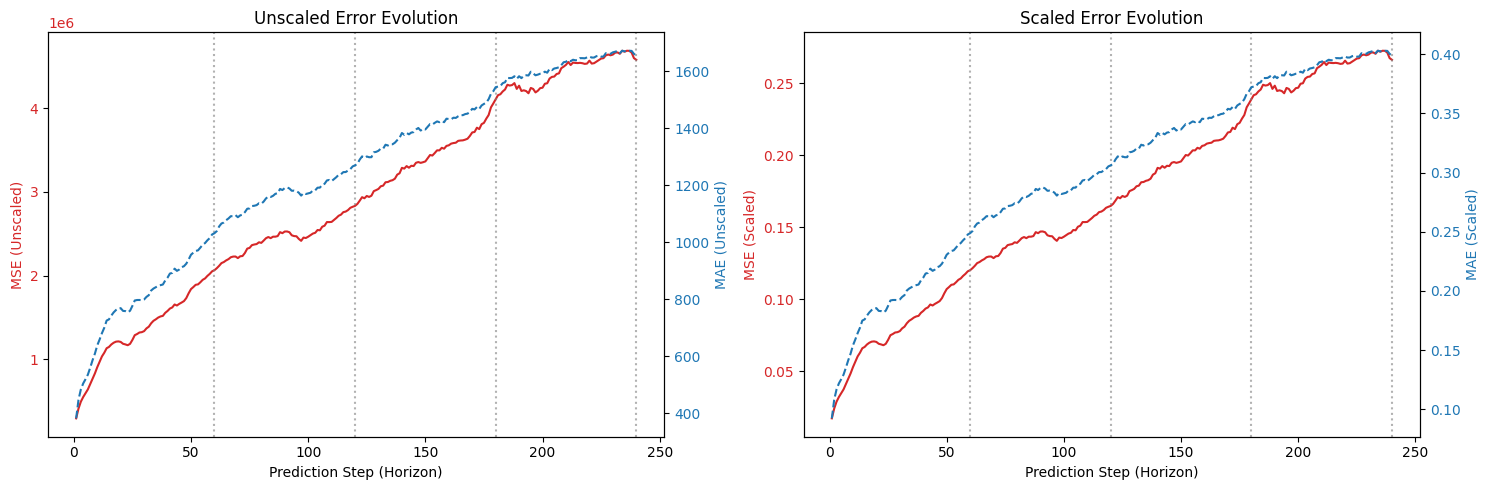


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_Baseline.jpg

📐 Stepwise eval: kernel_size_3


Testing: 100%|██████████| 101/101 [00:00<00:00, 534.21it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1759 | Overall MAE = 0.3076
[Unscaled] Overall MSE = 3025803.7858 | Overall MAE = 1275.6151 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1269 | MAE = 0.2560
  Unscaled -> MSE = 2182067.1118 | MAE = 1061.6565
Step 120:
  Scaled   -> MSE = 0.1689 | MAE = 0.3095
  Unscaled -> MSE = 2904188.3814 | MAE = 1283.4201
Step 180:
  Scaled   -> MSE = 0.2414 | MAE = 0.3739
  Unscaled -> MSE = 4151296.4114 | MAE = 1550.7418
Step 240:
  Scaled   -> MSE = 0.2766 | MAE = 0.4080
  Unscaled -> MSE = 4757089.5549 | MAE = 1692.0287


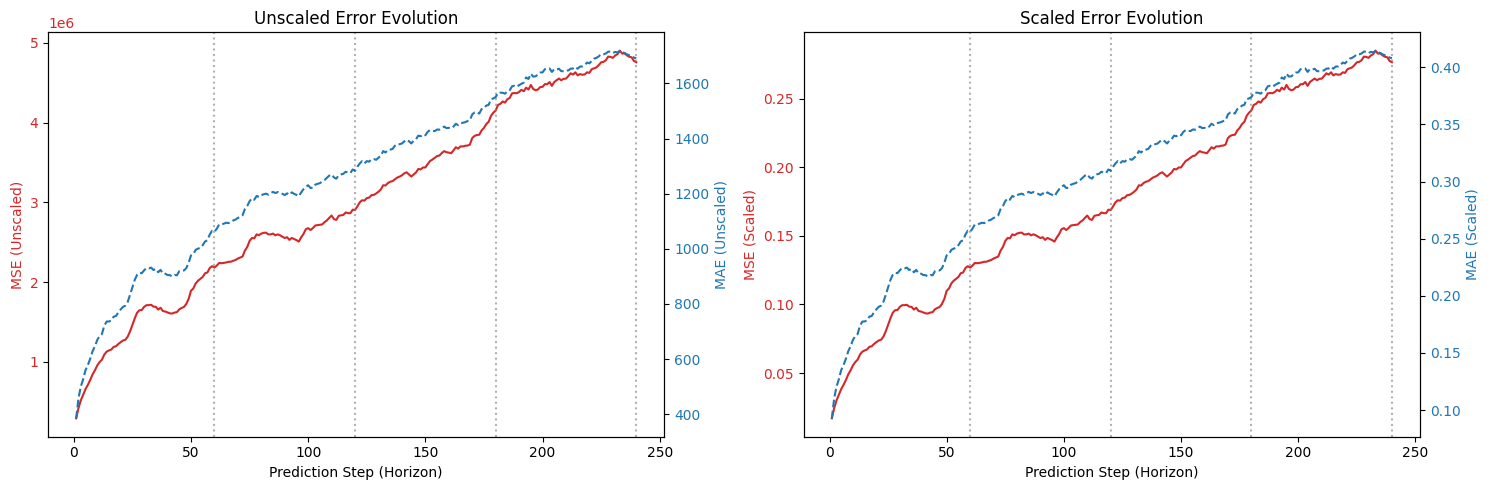


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_kernel_size_3.jpg

📐 Stepwise eval: kernel_size_5


Testing: 100%|██████████| 101/101 [00:00<00:00, 541.96it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1742 | Overall MAE = 0.3027
[Unscaled] Overall MSE = 2995730.1751 | Overall MAE = 1255.1496 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1228 | MAE = 0.2519
  Unscaled -> MSE = 2112707.1390 | MAE = 1044.5704
Step 120:
  Scaled   -> MSE = 0.1660 | MAE = 0.3062
  Unscaled -> MSE = 2854728.5231 | MAE = 1269.8849
Step 180:
  Scaled   -> MSE = 0.2433 | MAE = 0.3671
  Unscaled -> MSE = 4184313.4726 | MAE = 1522.2857
Step 240:
  Scaled   -> MSE = 0.2757 | MAE = 0.4039
  Unscaled -> MSE = 4741213.9442 | MAE = 1674.8932


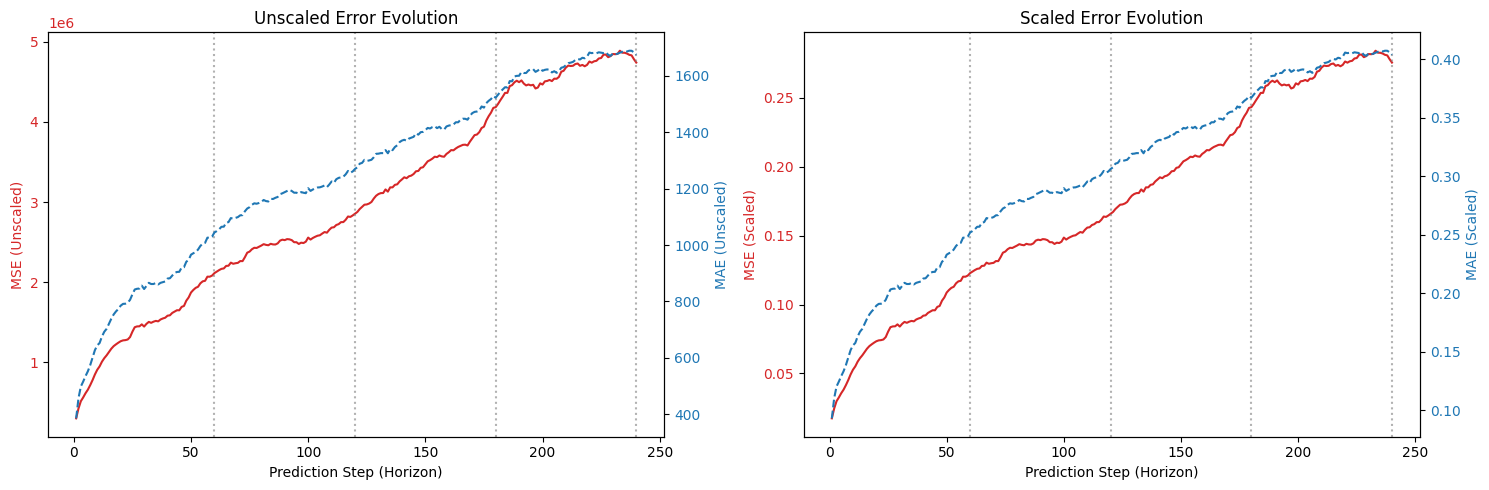


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_kernel_size_5.jpg

📐 Stepwise eval: kernel_size_11


Testing: 100%|██████████| 101/101 [00:00<00:00, 521.29it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1812 | Overall MAE = 0.3100
[Unscaled] Overall MSE = 3116503.5113 | Overall MAE = 1285.5806 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1213 | MAE = 0.2510
  Unscaled -> MSE = 2086918.3450 | MAE = 1041.0374
Step 120:
  Scaled   -> MSE = 0.1785 | MAE = 0.3189
  Unscaled -> MSE = 3070094.3898 | MAE = 1322.6970
Step 180:
  Scaled   -> MSE = 0.2586 | MAE = 0.3873
  Unscaled -> MSE = 4447516.2306 | MAE = 1606.1758
Step 240:
  Scaled   -> MSE = 0.2896 | MAE = 0.4200
  Unscaled -> MSE = 4981226.3489 | MAE = 1741.8072


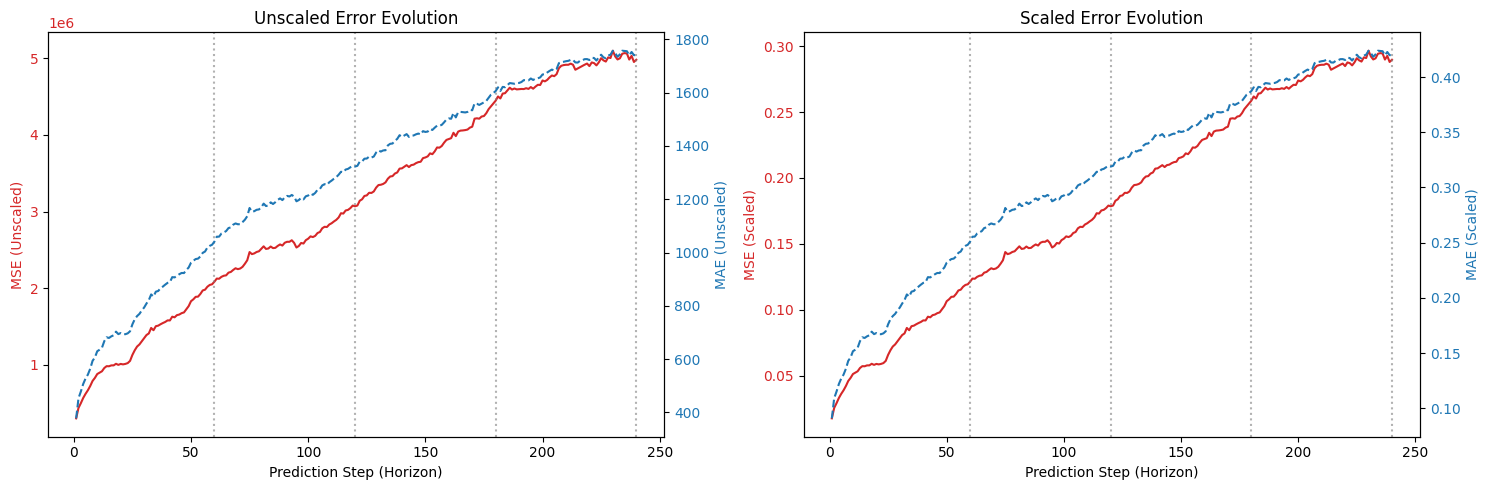


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_kernel_size_11.jpg

📐 Stepwise eval: GCN_Layer_1


Testing: 100%|██████████| 101/101 [00:00<00:00, 586.13it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1692 | Overall MAE = 0.2976
[Unscaled] Overall MSE = 2909983.5833 | Overall MAE = 1234.1114 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1173 | MAE = 0.2455
  Unscaled -> MSE = 2016671.2371 | MAE = 1018.2315
Step 120:
  Scaled   -> MSE = 0.1663 | MAE = 0.3064
  Unscaled -> MSE = 2859846.0185 | MAE = 1270.6754
Step 180:
  Scaled   -> MSE = 0.2403 | MAE = 0.3679
  Unscaled -> MSE = 4133092.0634 | MAE = 1525.7130
Step 240:
  Scaled   -> MSE = 0.2674 | MAE = 0.3970
  Unscaled -> MSE = 4597980.8947 | MAE = 1646.5045


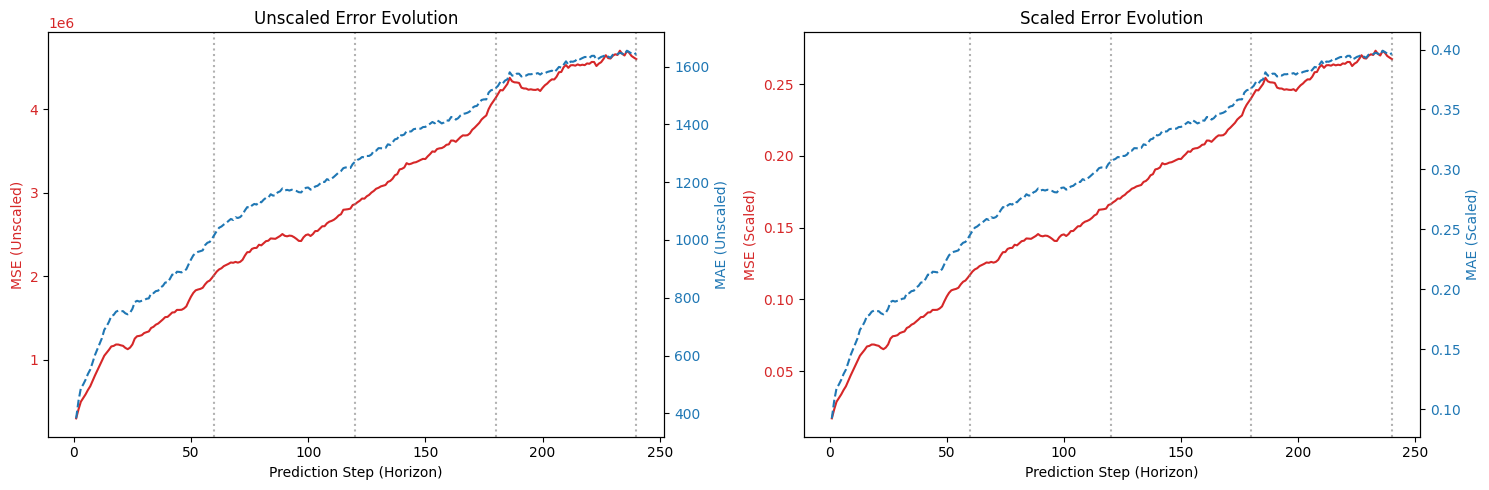


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_GCN_Layer_1.jpg

📐 Stepwise eval: GCN_Layer_2


Testing: 100%|██████████| 101/101 [00:00<00:00, 422.08it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1645 | Overall MAE = 0.2949
[Unscaled] Overall MSE = 2829884.3787 | Overall MAE = 1223.1088 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1193 | MAE = 0.2473
  Unscaled -> MSE = 2051152.1729 | MAE = 1025.6529
Step 120:
  Scaled   -> MSE = 0.1594 | MAE = 0.3007
  Unscaled -> MSE = 2742119.5612 | MAE = 1247.0388
Step 180:
  Scaled   -> MSE = 0.2281 | MAE = 0.3609
  Unscaled -> MSE = 3922316.6246 | MAE = 1496.8115
Step 240:
  Scaled   -> MSE = 0.2600 | MAE = 0.3929
  Unscaled -> MSE = 4471516.0784 | MAE = 1629.2488


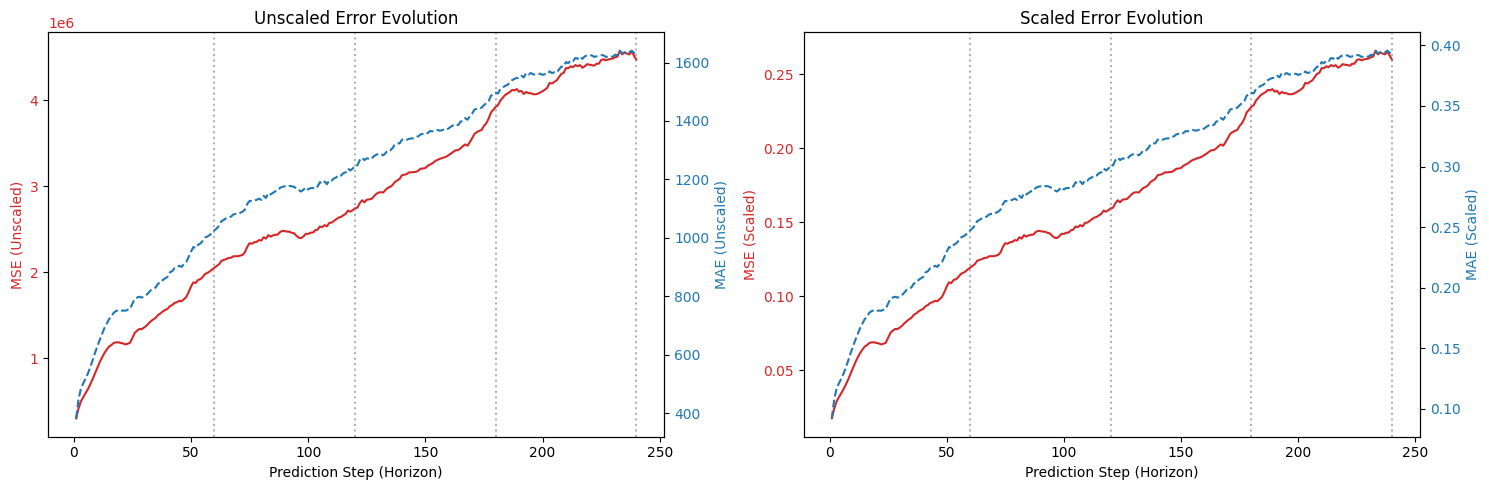


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_GCN_Layer_2.jpg

📐 Stepwise eval: GCN_Layer_3


Testing: 100%|██████████| 101/101 [00:00<00:00, 572.62it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1664 | Overall MAE = 0.2957
[Unscaled] Overall MSE = 2861791.0424 | Overall MAE = 1226.4796 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1179 | MAE = 0.2457
  Unscaled -> MSE = 2026991.4417 | MAE = 1018.8056
Step 120:
  Scaled   -> MSE = 0.1635 | MAE = 0.3026
  Unscaled -> MSE = 2811573.0569 | MAE = 1255.0898
Step 180:
  Scaled   -> MSE = 0.2346 | MAE = 0.3646
  Unscaled -> MSE = 4034684.4956 | MAE = 1512.1512
Step 240:
  Scaled   -> MSE = 0.2611 | MAE = 0.3931
  Unscaled -> MSE = 4490430.1556 | MAE = 1630.3391


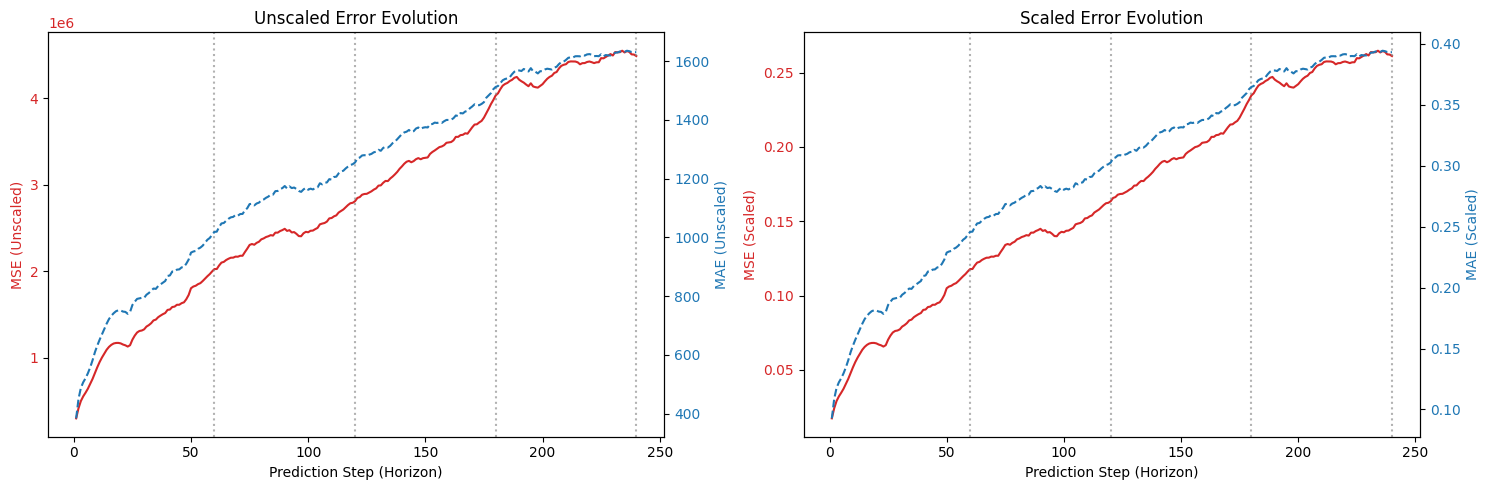


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_GCN_Layer_3.jpg

📐 Stepwise eval: GCN_Layer_7


Testing: 100%|██████████| 101/101 [00:00<00:00, 540.98it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1722 | Overall MAE = 0.3011
[Unscaled] Overall MSE = 2962275.7969 | Overall MAE = 1248.7223 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1218 | MAE = 0.2484
  Unscaled -> MSE = 2095205.0952 | MAE = 1029.9834
Step 120:
  Scaled   -> MSE = 0.1689 | MAE = 0.3078
  Unscaled -> MSE = 2903939.5457 | MAE = 1276.6488
Step 180:
  Scaled   -> MSE = 0.2412 | MAE = 0.3708
  Unscaled -> MSE = 4148970.1353 | MAE = 1537.8696
Step 240:
  Scaled   -> MSE = 0.2716 | MAE = 0.4031
  Unscaled -> MSE = 4671645.1085 | MAE = 1671.5916


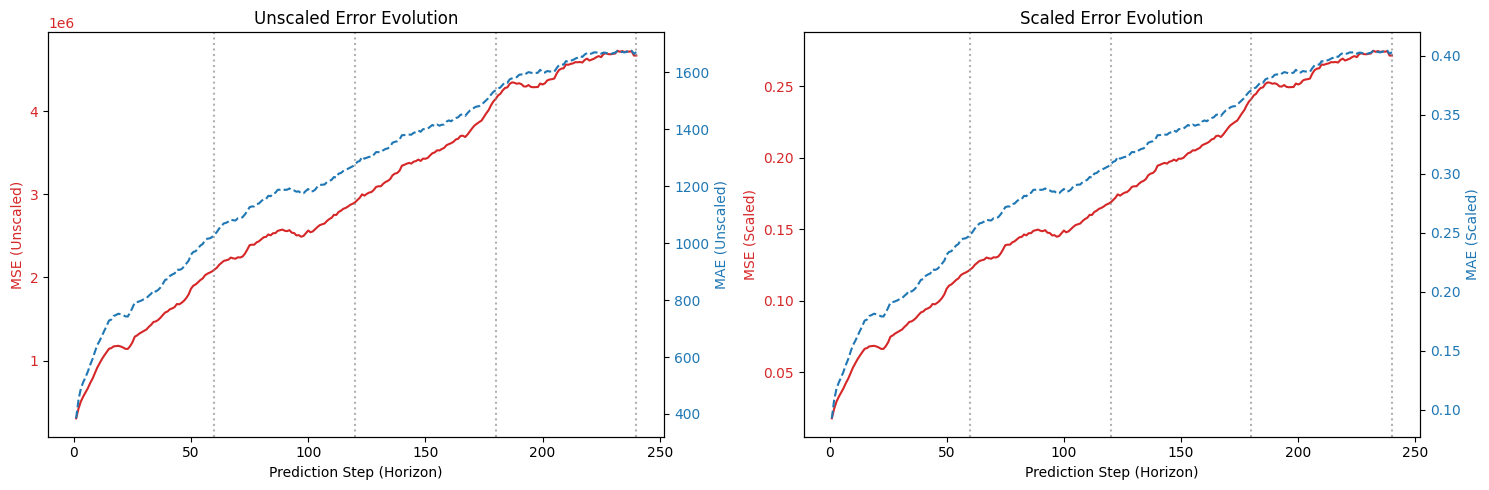


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_GCN_Layer_7.jpg

📐 Stepwise eval: dilation_1


Testing: 100%|██████████| 101/101 [00:00<00:00, 581.05it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1829 | Overall MAE = 0.3140
[Unscaled] Overall MSE = 3145254.6748 | Overall MAE = 1302.2982 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1268 | MAE = 0.2548
  Unscaled -> MSE = 2180169.0108 | MAE = 1056.8392
Step 120:
  Scaled   -> MSE = 0.1748 | MAE = 0.3174
  Unscaled -> MSE = 3006463.5701 | MAE = 1316.2162
Step 180:
  Scaled   -> MSE = 0.2529 | MAE = 0.3830
  Unscaled -> MSE = 4349975.0762 | MAE = 1588.4339
Step 240:
  Scaled   -> MSE = 0.2920 | MAE = 0.4231
  Unscaled -> MSE = 5022195.8175 | MAE = 1754.4433


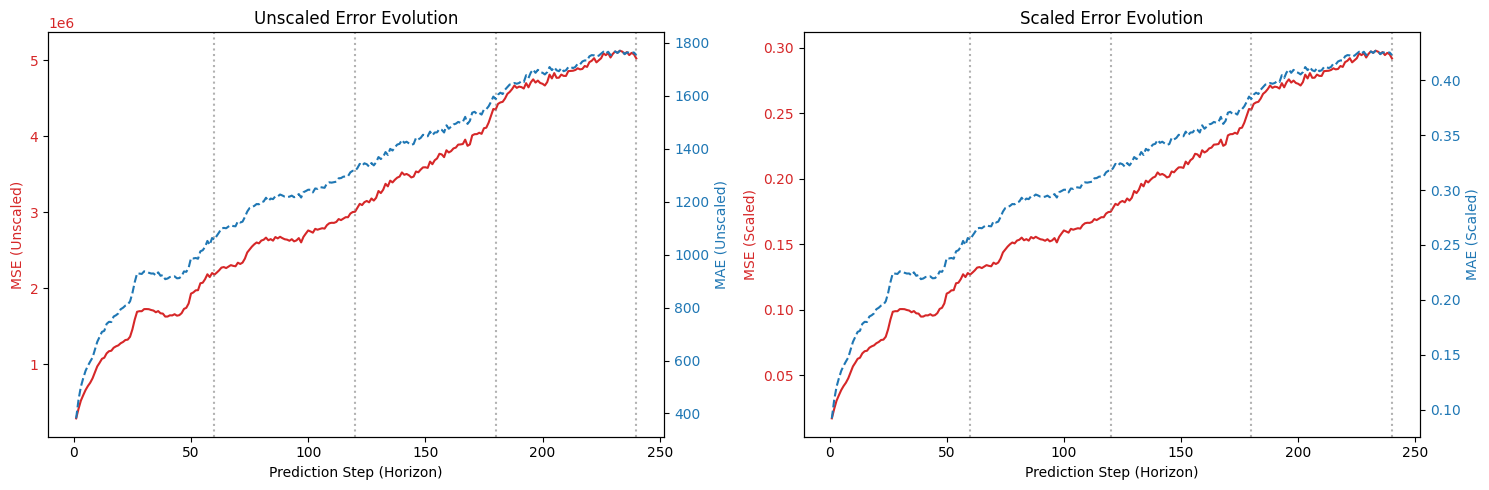


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_dilation_1.jpg

📐 Stepwise eval: dilation_2


Testing: 100%|██████████| 101/101 [00:00<00:00, 601.31it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1674 | Overall MAE = 0.2968
[Unscaled] Overall MSE = 2878918.2175 | Overall MAE = 1230.8524 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1183 | MAE = 0.2481
  Unscaled -> MSE = 2033685.7561 | MAE = 1028.8607
Step 120:
  Scaled   -> MSE = 0.1580 | MAE = 0.2985
  Unscaled -> MSE = 2718026.8132 | MAE = 1237.8470
Step 180:
  Scaled   -> MSE = 0.2349 | MAE = 0.3653
  Unscaled -> MSE = 4039237.6101 | MAE = 1514.8976
Step 240:
  Scaled   -> MSE = 0.2638 | MAE = 0.3920
  Unscaled -> MSE = 4536110.8582 | MAE = 1625.7299


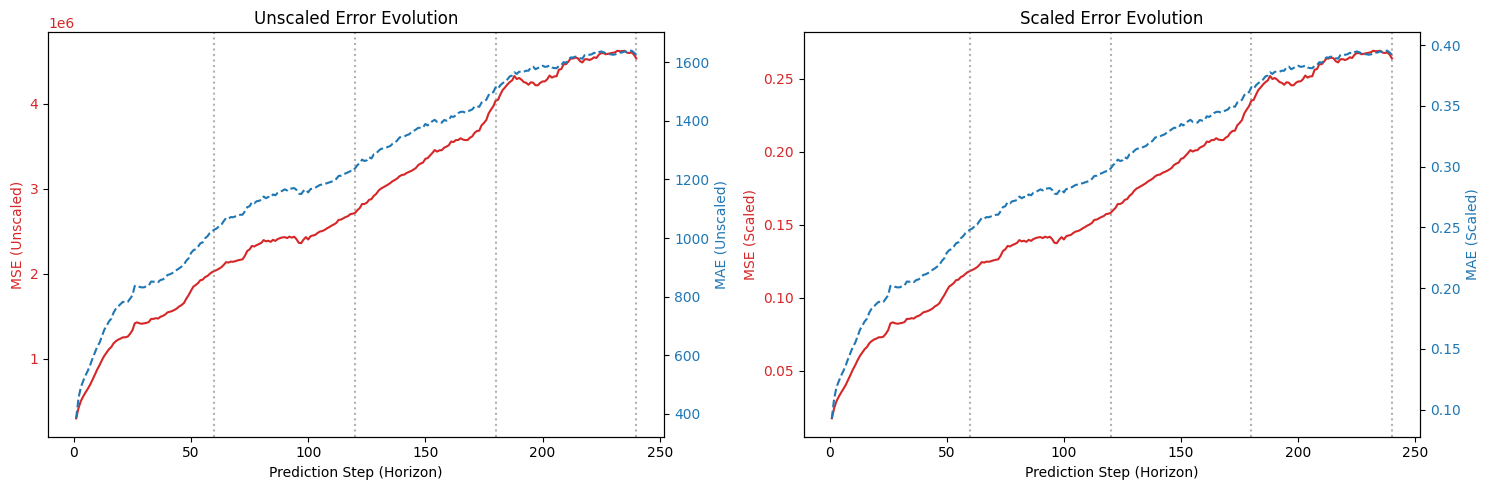


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_dilation_2.jpg

📐 Stepwise eval: dilation_5


Testing: 100%|██████████| 101/101 [00:00<00:00, 507.42it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1761 | Overall MAE = 0.3050
[Unscaled] Overall MSE = 3028297.0739 | Overall MAE = 1265.0290 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1190 | MAE = 0.2476
  Unscaled -> MSE = 2046303.7158 | MAE = 1026.7459
Step 120:
  Scaled   -> MSE = 0.1754 | MAE = 0.3150
  Unscaled -> MSE = 3016960.4516 | MAE = 1306.3864
Step 180:
  Scaled   -> MSE = 0.2508 | MAE = 0.3813
  Unscaled -> MSE = 4313429.7208 | MAE = 1581.4487
Step 240:
  Scaled   -> MSE = 0.2768 | MAE = 0.4054
  Unscaled -> MSE = 4760427.5470 | MAE = 1681.3335


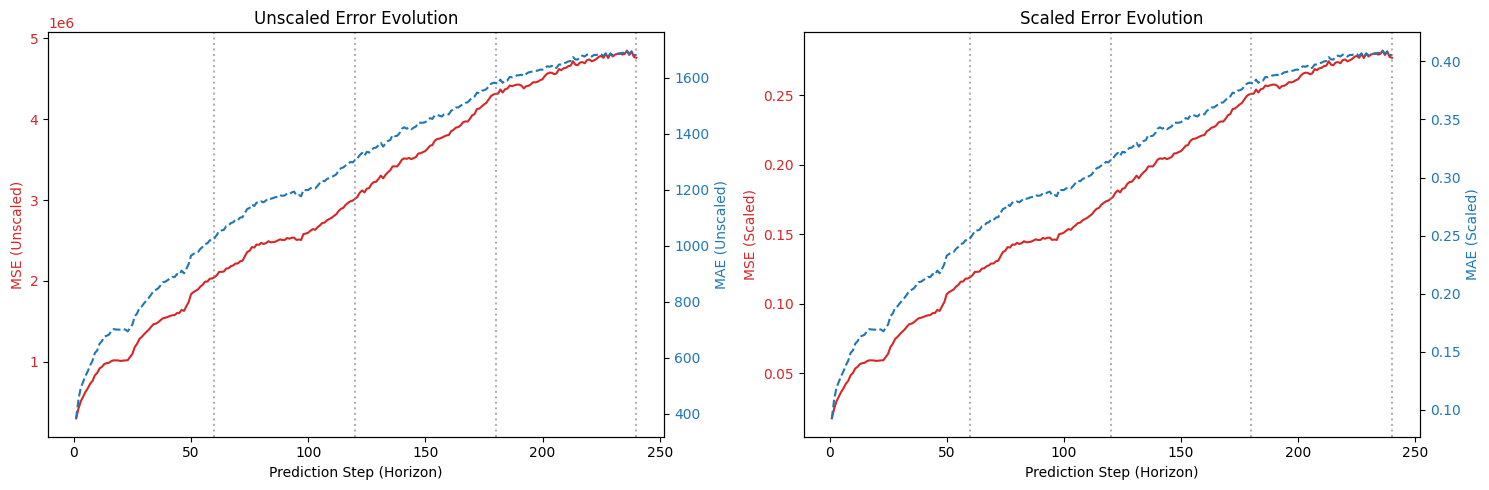


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_dilation_5.jpg

📐 Stepwise eval: hidden_dim_32


Testing: 100%|██████████| 101/101 [00:00<00:00, 556.13it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1602 | Overall MAE = 0.2948
[Unscaled] Overall MSE = 2755114.2626 | Overall MAE = 1222.4536 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1203 | MAE = 0.2489
  Unscaled -> MSE = 2069404.8540 | MAE = 1032.2132
Step 120:
  Scaled   -> MSE = 0.1550 | MAE = 0.2994
  Unscaled -> MSE = 2665302.0259 | MAE = 1241.7321
Step 180:
  Scaled   -> MSE = 0.2192 | MAE = 0.3604
  Unscaled -> MSE = 3770497.7317 | MAE = 1494.4764
Step 240:
  Scaled   -> MSE = 0.2496 | MAE = 0.3908
  Unscaled -> MSE = 4291883.5198 | MAE = 1620.5706


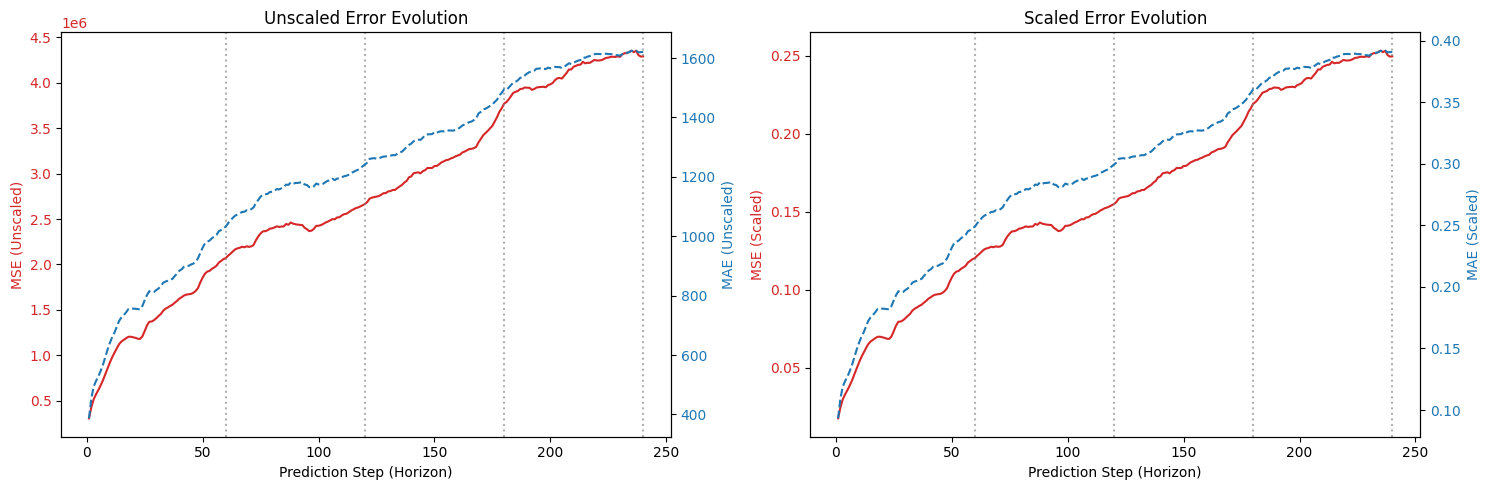


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_hidden_dim_32.jpg

📐 Stepwise eval: hidden_dim_128


Testing: 100%|██████████| 101/101 [00:00<00:00, 554.61it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1687 | Overall MAE = 0.2995
[Unscaled] Overall MSE = 2901039.3058 | Overall MAE = 1242.0591 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1197 | MAE = 0.2484
  Unscaled -> MSE = 2057831.9941 | MAE = 1030.0283
Step 120:
  Scaled   -> MSE = 0.1619 | MAE = 0.3050
  Unscaled -> MSE = 2784278.4351 | MAE = 1264.8739
Step 180:
  Scaled   -> MSE = 0.2360 | MAE = 0.3672
  Unscaled -> MSE = 4059329.7178 | MAE = 1522.9750
Step 240:
  Scaled   -> MSE = 0.2699 | MAE = 0.4010
  Unscaled -> MSE = 4641054.4856 | MAE = 1663.0668


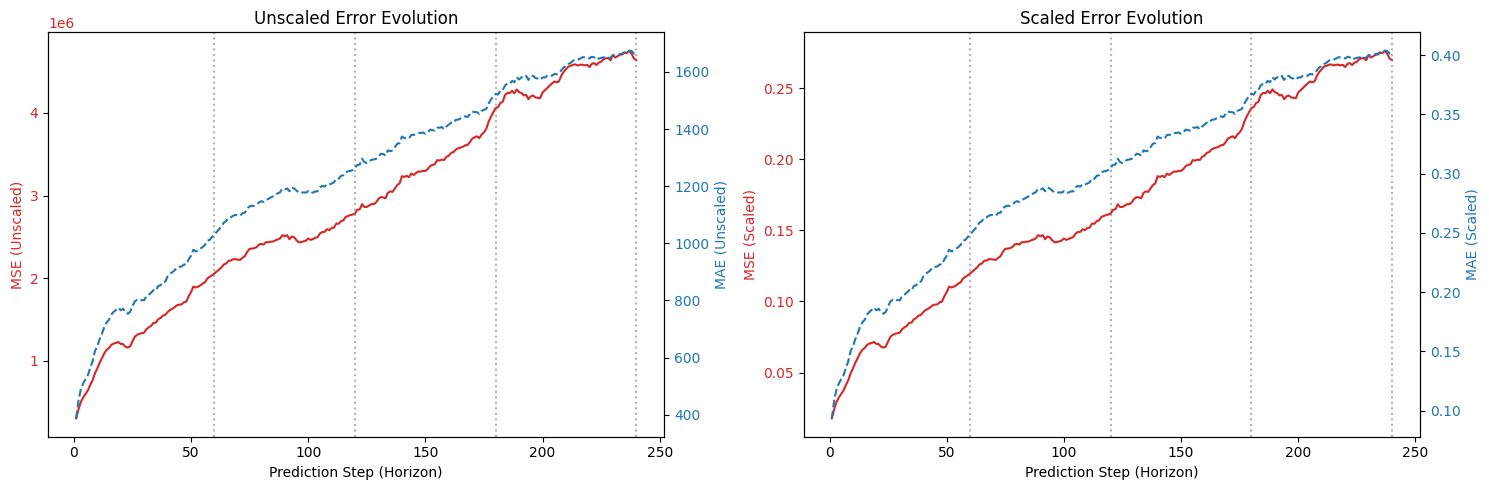


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_hidden_dim_128.jpg

📐 Stepwise eval: hidden_dim_256


Testing: 100%|██████████| 101/101 [00:00<00:00, 417.52it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.1779 | Overall MAE = 0.3079
[Unscaled] Overall MSE = 3059034.6581 | Overall MAE = 1276.8952 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1233 | MAE = 0.2548
  Unscaled -> MSE = 2120453.0185 | MAE = 1056.6020
Step 120:
  Scaled   -> MSE = 0.1719 | MAE = 0.3146
  Unscaled -> MSE = 2956146.8075 | MAE = 1304.5408
Step 180:
  Scaled   -> MSE = 0.2514 | MAE = 0.3808
  Unscaled -> MSE = 4323484.8908 | MAE = 1579.0556
Step 240:
  Scaled   -> MSE = 0.2840 | MAE = 0.4123
  Unscaled -> MSE = 4883506.6648 | MAE = 1710.0178


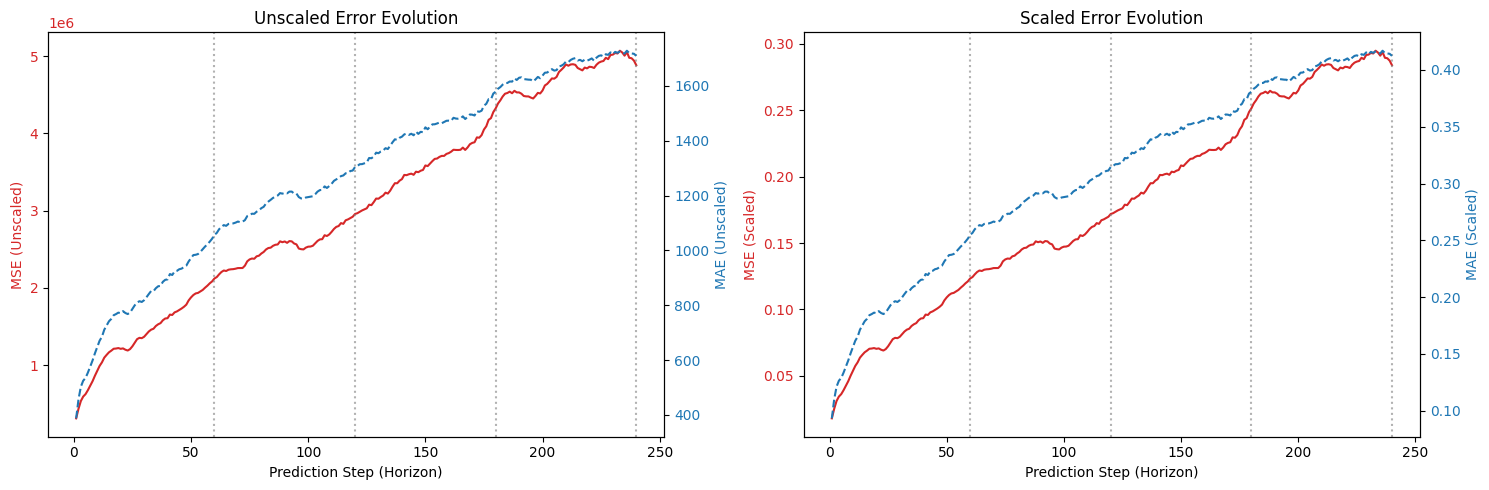


Plots saved to Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_error_hidden_dim_256.jpg

📊 Grouped stepwise-error comparison plots


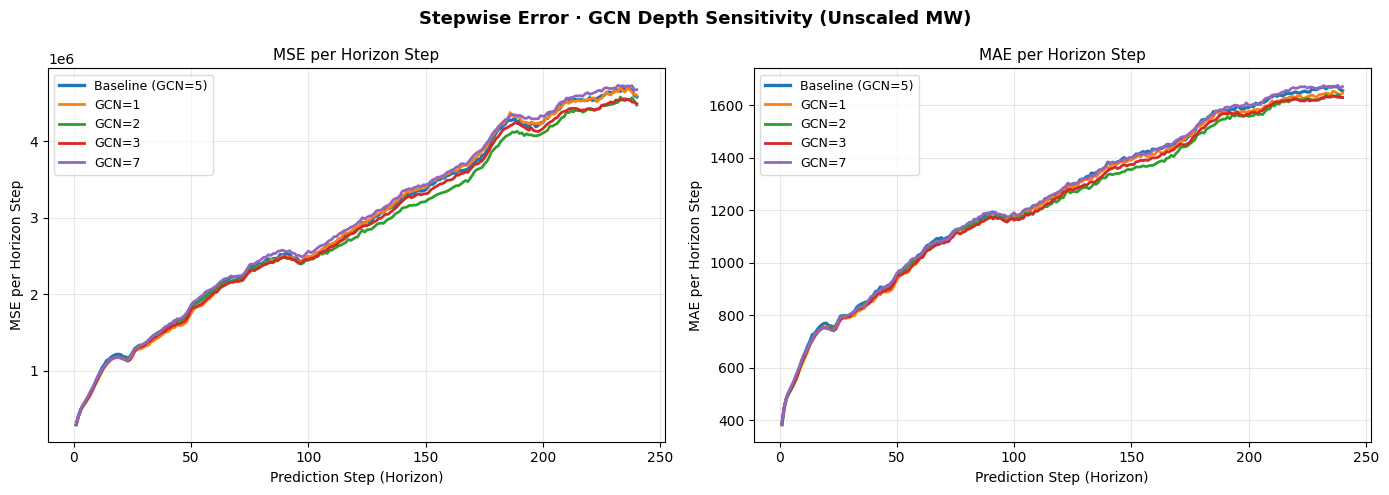

   📈 Saved: Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_compare_gcn_depth.png


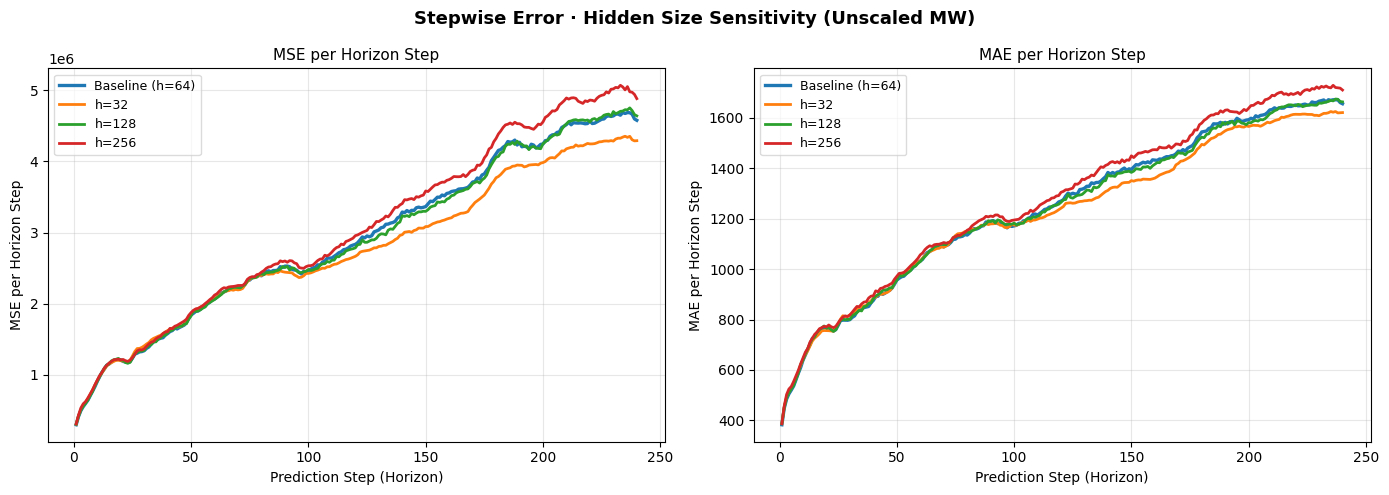

   📈 Saved: Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_compare_hidden_size.png


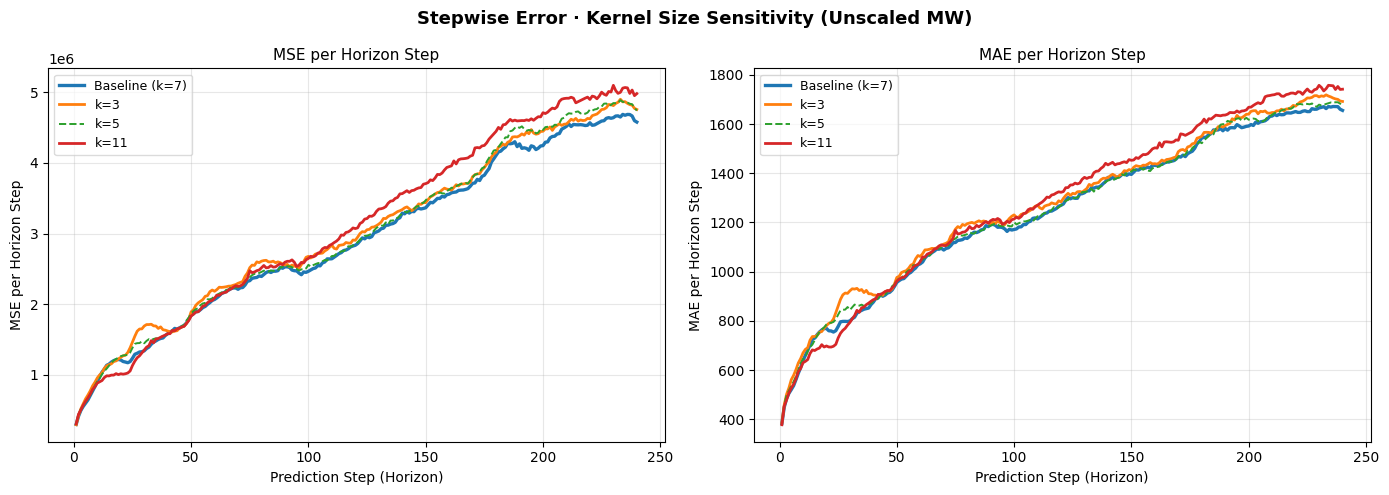

   📈 Saved: Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_compare_kernel_size.png


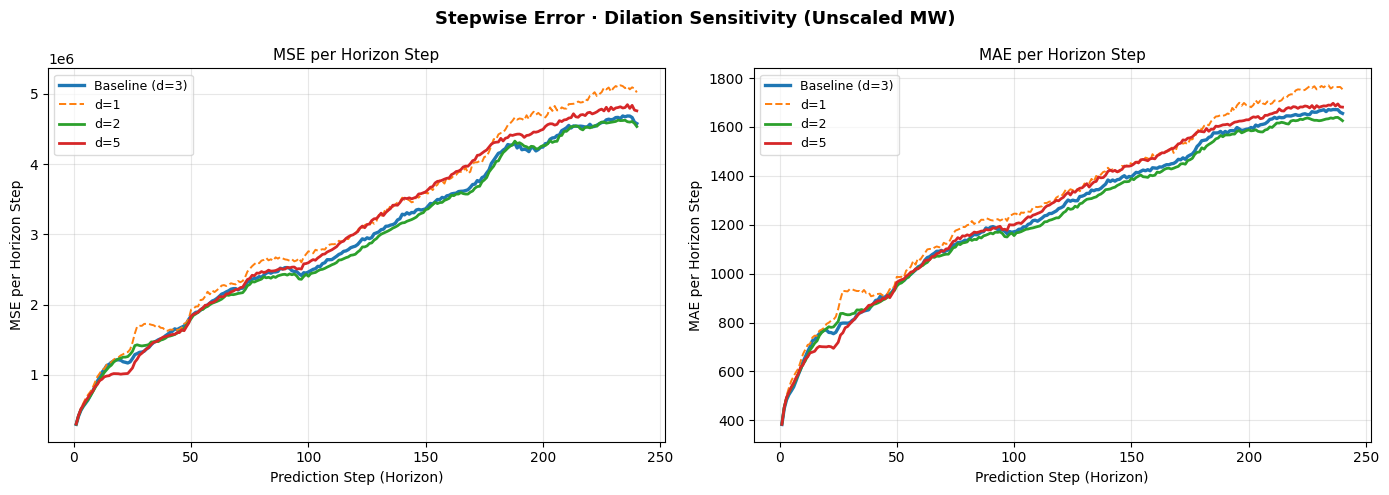

   📈 Saved: Intial_Paper/TR_GNN_SH_Sensitivity/stepwise_errors/stepwise_compare_dilation.png

✅ Stepwise sensitivity evaluation complete.


In [9]:
# ============================================================
# SENSITIVITY SH — Stepwise (per-horizon) Error for ALL configs
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
stepwise_dir = os.path.join(SAVE_DIR, "stepwise_errors")
os.makedirs(stepwise_dir, exist_ok=True)

ok_items = [(k, v) for k, v in all_results.items() if v.get("status") == "OK"]
if not ok_items:
    raise RuntimeError("No OK configurations found in all_results.")

# --- Run test_model_stepwise for every config ---
for cfg_name, cfg in ok_items:
    print(f"\n{'='*60}\n📐 Stepwise eval: {cfg_name}\n{'='*60}")

    hparams = {
        **static_hparams,
        "GCN_Layer":   cfg["GCN_Layer"],
        "hidden_dim":  cfg["hidden_dim"],
        "kernel_size": cfg["kernel_size"],
        "dilation":    cfg["dilation"],
    }

    model = TR_GNN_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
        kernel_size=hparams["kernel_size"],
        dilation=hparams["dilation"],
    ).to(device)
    model.load_state_dict(torch.load(cfg["model_path"], map_location=device))

    save_plot_path = os.path.join(stepwise_dir, f"stepwise_error_{cfg_name}.jpg")
    _, _, mse_per_step, mae_per_step = test_model_stepwise(
        dataset=dataset,
        model=model,
        test_loader=test_loader,
        device=device,
        save_plot_path=save_plot_path,
    )

    cfg["mse_per_step"] = mse_per_step
    cfg["mae_per_step"] = mae_per_step

# --- Grouped comparison plots (Baseline vs each variant) ---
groups = {
    "GCN Depth":   {"Baseline": "Baseline (GCN=5)", "GCN_Layer_1": "GCN=1",
                    "GCN_Layer_2": "GCN=2", "GCN_Layer_3": "GCN=3",
                    "GCN_Layer_7": "GCN=7"},
    "Hidden Size": {"Baseline": "Baseline (h=64)", "hidden_dim_32": "h=32",
                    "hidden_dim_128": "h=128", "hidden_dim_256": "h=256"},
    "Kernel Size": {"Baseline": "Baseline (k=7)", "kernel_size_3": "k=3",
                    "kernel_size_5": "k=5", "kernel_size_11": "k=11"},
    "Dilation":    {"Baseline": "Baseline (d=3)", "dilation_1": "d=1",
                    "dilation_2": "d=2", "dilation_5": "d=5"},
}
GROUP_COLORS = plt.cm.tab10.colors

print(f"\n{'='*60}\n📊 Grouped stepwise-error comparison plots\n{'='*60}")
for group_name, cfg_label_map in groups.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Stepwise Error · {group_name} Sensitivity (Unscaled MW)",
                 fontsize=13, fontweight="bold")

    for ax, metric_key, panel_title in zip(
        axes,
        ["mse_per_step", "mae_per_step"],
        ["MSE per Horizon Step", "MAE per Horizon Step"],
    ):
        for ci, (cfg_name, label) in enumerate(cfg_label_map.items()):
            r = all_results.get(cfg_name)
            if r is None or r.get(metric_key) is None:
                continue
            curve = r[metric_key]
            is_baseline = (cfg_name == "Baseline")
            beats = r.get("beats_baseline", False)
            lw = 2.4 if is_baseline else (2.0 if beats else 1.4)
            ls = "-" if (is_baseline or beats) else "--"
            ax.plot(
                np.arange(1, len(curve) + 1), curve,
                color=GROUP_COLORS[ci % len(GROUP_COLORS)],
                linewidth=lw, linestyle=ls, label=label,
            )
        ax.set_xlabel("Prediction Step (Horizon)", fontsize=10)
        ax.set_ylabel(panel_title, fontsize=10)
        ax.set_title(panel_title, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, framealpha=0.7)

    plt.tight_layout()
    fname = f"stepwise_compare_{group_name.replace(' ', '_').lower()}.png"
    out_path = os.path.join(stepwise_dir, fname)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   📈 Saved: {out_path}")

print("\n✅ Stepwise sensitivity evaluation complete.")

In [6]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Paths and split settings
# ----------------------------
SAVE_DIR = "Intial_Paper/TR_GNN_SH_Sensitivity"
JSON_PATH = os.path.join(SAVE_DIR, "all_results.json")
CSV_PATH = os.path.join(SAVE_DIR, "sensitivity_analysis_results.csv")

# must match training notebook exactly
TRAIN_FRAC = 0.6

# ----------------------------
# Rebuild dataset + scaler
# ----------------------------
dataset = SH_Dataset(
    csv_path="sh_dataset.csv",
    T_in=72,
    T_out=240,
    lag_hours=[1, 12, 24, 168],
    rolling_windows=[12, 24],
)

total_len = len(dataset.df_numeric)
train_split_idx = int(TRAIN_FRAC * total_len)

scaler = StandardScaler()
scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

target_idx = dataset.target_idx   # load column index
sigma = float(scaler.scale_[target_idx])

print(f"Target idx: {target_idx}, sigma: {sigma:.6f}")

# ----------------------------
# Load saved results
# ----------------------------
with open(JSON_PATH, "r") as f:
    all_results = json.load(f)

# ----------------------------
# Convert metrics + rebuild table
# ----------------------------
BASELINE_VAL_LOSS = all_results.get("Baseline", {}).get("best_val_loss", float("inf"))

rows = []
for cfg_name, r in all_results.items():
    if r.get("status") != "OK":
        continue

    test_mse_unscaled = r.get("test_mse", np.nan)
    test_mae_unscaled = r.get("test_mae", np.nan)

    test_mse_scaled = (
        float(test_mse_unscaled) / (sigma ** 2)
        if pd.notna(test_mse_unscaled) else np.nan
    )
    test_mae_scaled = (
        float(test_mae_unscaled) / sigma
        if pd.notna(test_mae_unscaled) else np.nan
    )

    rows.append({
        "config": cfg_name,
        "GCN_Layer": r.get("GCN_Layer"),
        "hidden_dim": r.get("hidden_dim"),
        "kernel_size": r.get("kernel_size"),
        "dilation": r.get("dilation"),
        "n_params": r.get("n_params"),
        "best_val_loss": r.get("best_val_loss"),              # already scaled
        "test_mse": r.get("test_mse"),                        # unscaled (MW^2)
        "test_mae": r.get("test_mae"),                        # unscaled (MW)
        "test_r2": r.get("test_r2"),                          # unchanged by scaling
        "test_mse_scaled": test_mse_scaled,                   # reconstructed
        "test_mae_scaled": test_mae_scaled,                   # reconstructed
        "avg_epoch_time_s": r.get("avg_epoch_time_s"),
        "peak_gpu_mem_mb": r.get("peak_gpu_mem_mb"),
        "avg_inference_ms": r.get("avg_inference_ms"),
        "model_path": r.get("model_path"),
        "beats_baseline": bool(r.get("best_val_loss", np.inf) < BASELINE_VAL_LOSS)
    })

df_results = pd.DataFrame(rows)

# optional: sort by val loss then scaled mse
df_results = df_results.sort_values(["best_val_loss", "test_mse_scaled"], ascending=[True, True])

# ----------------------------
# Save updated CSV (same name)
# ----------------------------
df_results.to_csv(CSV_PATH, index=False)
print(f"✅ CSV saved → {CSV_PATH}")

# display key columns
display_cols = [
    "config",
    "best_val_loss",
    "test_mse_scaled",
    "test_mae_scaled",
    "test_mse",
    "test_mae",
    "test_r2",
    "beats_baseline",
]
display(df_results[display_cols].reset_index(drop=True))

Loaded dataset with 25 features (target=load), total rows=17258
Target idx: 0, sigma: 4147.032846
✅ CSV saved → Intial_Paper/TR_GNN_SH_Sensitivity/sensitivity_analysis_results.csv


,config,best_val_loss,test_mse_scaled,test_mae_scaled,test_mse,test_mae,test_r2,beats_baseline
0,hidden_dim_32,0.200926,0.160201,0.294778,2.755114e+06,1222.453567,0.815322,True
1,dilation_5,0.202336,0.176085,0.305044,3.028297e+06,1265.028984,0.797010,True
2,GCN_Layer_7,0.202924,0.172247,0.301112,2.962276e+06,1248.722261,0.801435,True
3,kernel_size_11,0.203656,0.181214,0.310000,3.116504e+06,1285.580594,0.791097,True
4,GCN_Layer_2,0.204650,0.164548,0.294936,2.829884e+06,1223.108802,0.810310,True
5,GCN_Layer_3,0.206066,0.166404,0.295749,2.861791e+06,1226.479639,0.808171,True
6,kernel_size_3,0.208062,0.175940,0.307597,3.025804e+06,1275.615067,0.797177,True
7,dilation_2,0.208294,0.167400,0.296803,2.878918e+06,1230.852417,0.807023,True
8,hidden_dim_128,0.208761,0.168686,0.299505,2.901039e+06,1242.059142,0.805540,True
9,hidden_dim_256,0.209785,0.177873,0.307906,3.059035e+06,1276.895241,0.794949,True
